# S6E8 - Predicting Smartphone Addiction
## Score: .96668

## Setup

In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("playground-series-s6e8")
TARGET = "addicted_label"

## Load Data

In [52]:
train = pd.read_csv(DATA_DIR / "train.csv", index_col="id")
test = pd.read_csv(DATA_DIR / "test.csv", index_col="id")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", index_col="id")

print(f"train: {train.shape}")
print(f"test:  {test.shape}")
train.head()

train: (691369, 13)
test:  (296302, 12)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
id,,,,,,,,,,,,,
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## Schema and Missingness

In [53]:
features = [c for c in train.columns if c != TARGET]
num_cols = train[features].select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in features if c not in num_cols]

overview = pd.DataFrame(
    {
        "dtype": train[features].dtypes.astype(str),
        "nunique": train[features].nunique(),
        "train_missing_pct": train[features].isna().mean().mul(100).round(2),
        "test_missing_pct": test[features].isna().mean().mul(100).round(2),
    }
)

print(f"numeric ({len(num_cols)}): {num_cols}")
print(f"categorical ({len(cat_cols)}): {cat_cols}")
overview

numeric (9): ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
categorical (3): ['gender', 'stress_level', 'academic_work_impact']


,dtype,nunique,train_missing_pct,test_missing_pct
age,float64,18,4.18,5.78
daily_screen_time_hours,float64,1389,13.86,11.07
social_media_hours,float64,721,19.38,16.00
gaming_hours,float64,401,18.34,20.05
work_study_hours,float64,600,7.45,9.37
sleep_hours,float64,451,6.43,7.58
notifications_per_day,float64,231,9.78,11.55
app_opens_per_day,float64,166,11.67,8.68
weekend_screen_time,float64,1437,16.21,17.11
gender,str,3,4.20,4.80


In [54]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


## Target Balance

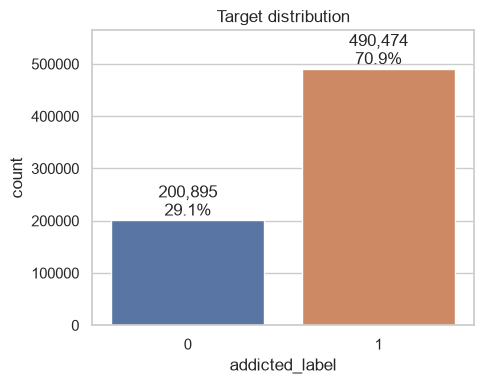

In [55]:
counts = train[TARGET].value_counts().sort_index()
rates = train[TARGET].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str), legend=False, ax=ax)
for i, (n, p) in enumerate(zip(counts.values, rates.values)):
    ax.text(i, n, f"{n:,}\n{p:.1%}", ha="center", va="bottom")
ax.set(xlabel=TARGET, ylabel="count", title="Target distribution")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Numeric Distributions by Target

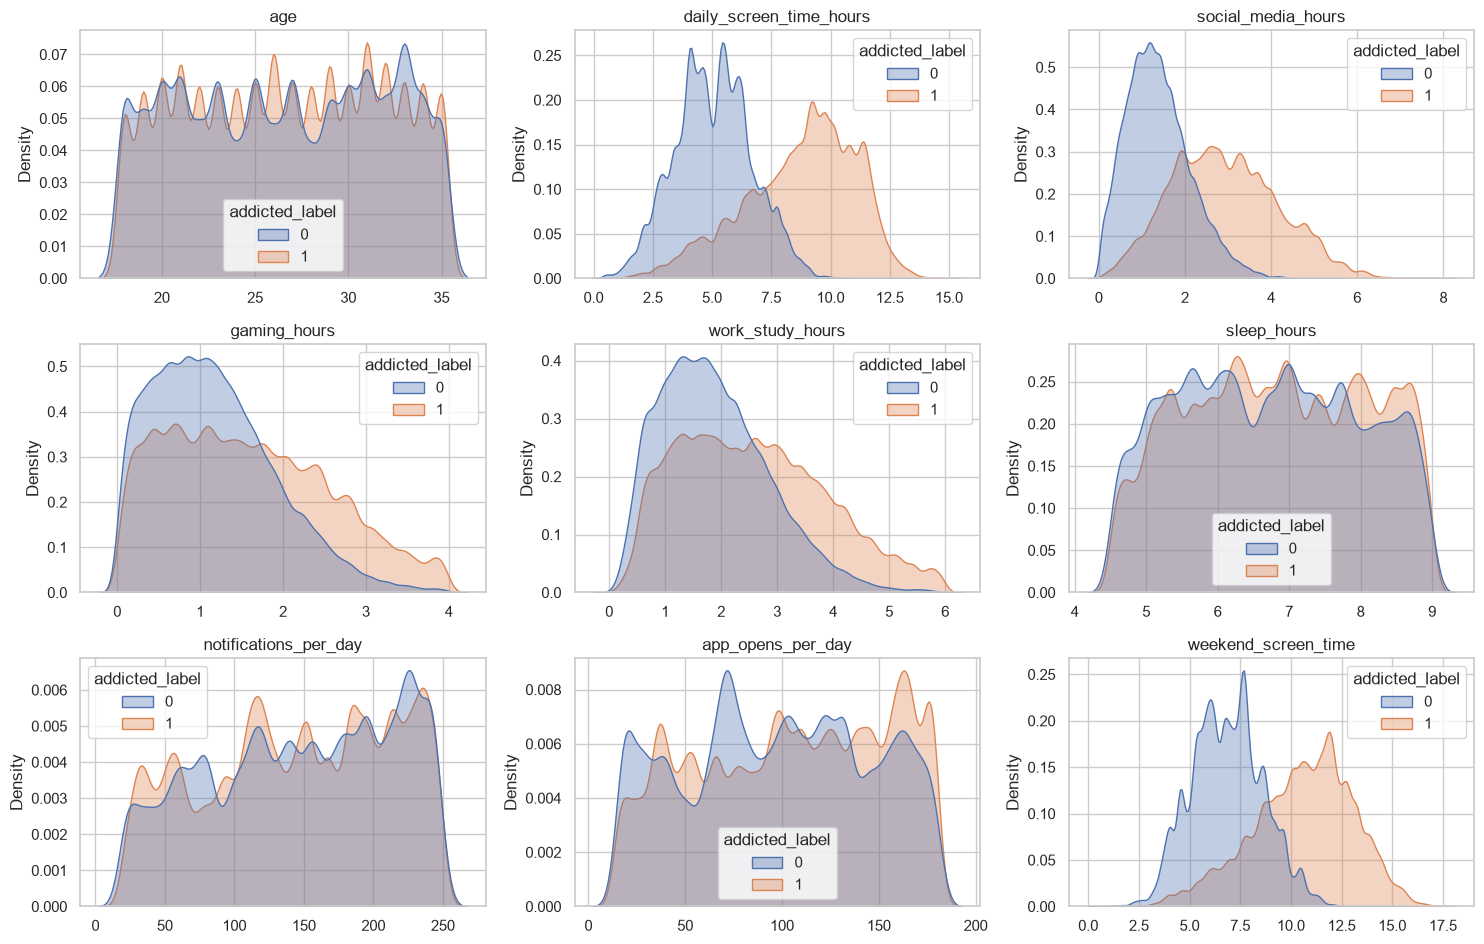

In [56]:
ncols = 3
nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows))

for ax, col in zip(axes.ravel(), num_cols):
    sns.kdeplot(data=train, x=col, hue=TARGET, common_norm=False, fill=True, alpha=0.35, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes.ravel()[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

## Categorical Features vs Target

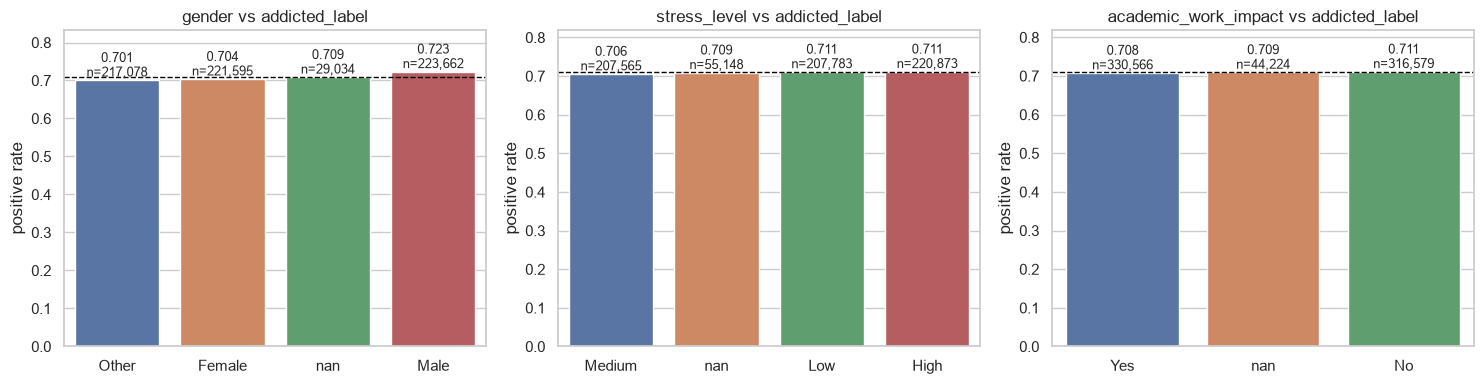

In [57]:
base_rate = train[TARGET].mean()
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(np.atleast_1d(axes), cat_cols):
    stats = train.groupby(col, dropna=False)[TARGET].agg(["mean", "size"]).sort_values("mean")
    labels = [str(i) for i in stats.index]
    sns.barplot(x=labels, y=stats["mean"].values, hue=labels, legend=False, ax=ax)
    ax.axhline(base_rate, ls="--", c="black", lw=1)
    for i, (m, n) in enumerate(zip(stats["mean"].values, stats["size"].values)):
        ax.text(i, m, f"{m:.3f}\nn={n:,}", ha="center", va="bottom", fontsize=9)
    ax.set(title=f"{col} vs {TARGET}", xlabel="", ylabel="positive rate")
    ax.margins(y=0.15)

plt.tight_layout()
plt.show()

## Correlation Matrix

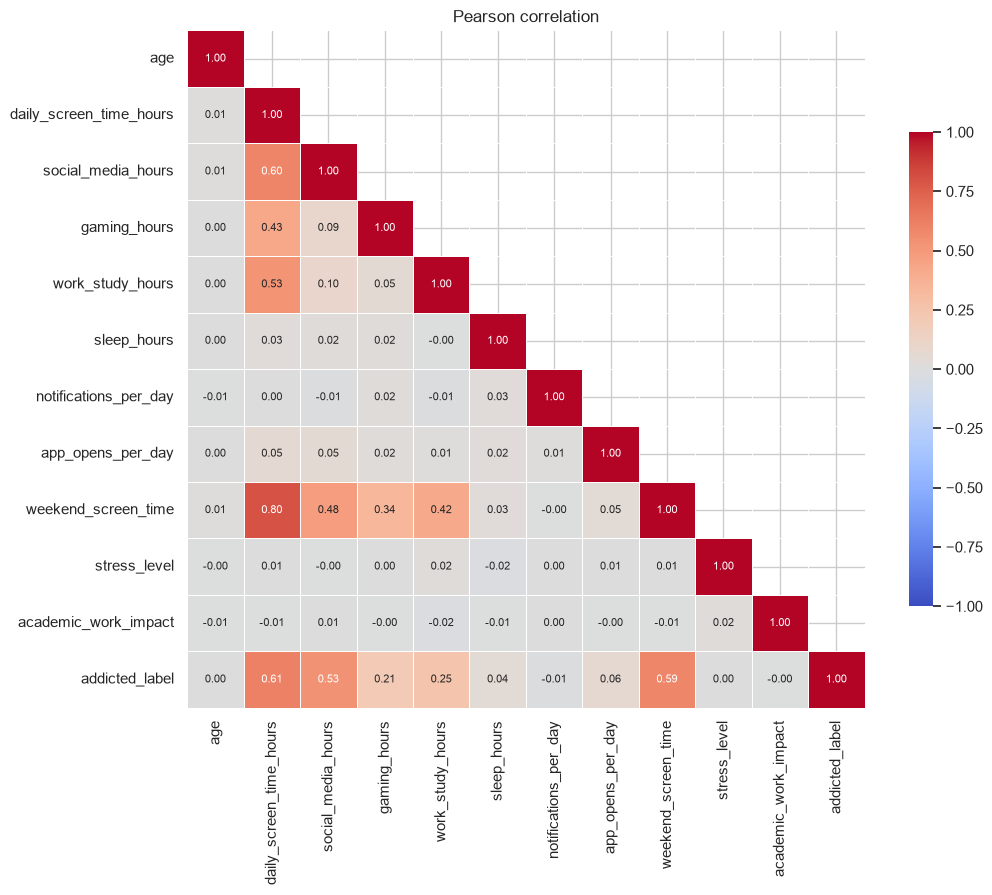

In [58]:
corr_df = train[num_cols].copy()
corr_df["stress_level"] = train["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
corr_df["academic_work_impact"] = train["academic_work_impact"].map({"No": 0, "Yes": 1})
corr_df[TARGET] = train[TARGET]

corr = corr_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title("Pearson correlation")
plt.tight_layout()
plt.show()

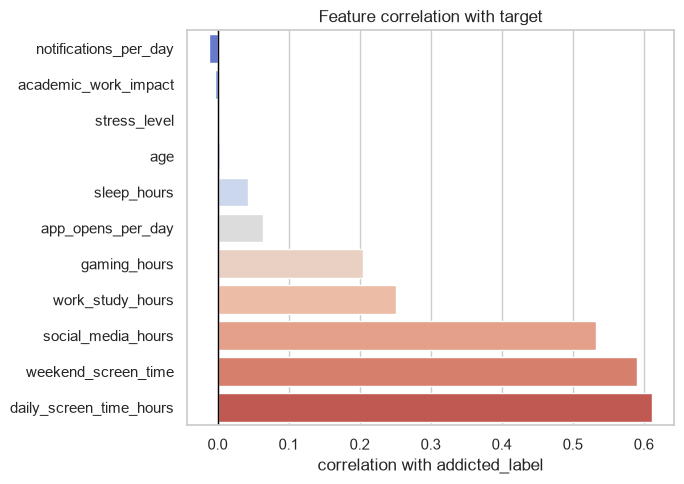

,corr
daily_screen_time_hours,0.611398
weekend_screen_time,0.589903
social_media_hours,0.532409
work_study_hours,0.251416
gaming_hours,0.205283
app_opens_per_day,0.063482
sleep_hours,0.042545
notifications_per_day,-0.011583
age,0.004043
academic_work_impact,-0.003464


In [59]:
target_corr = corr[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, legend=False, palette="coolwarm", ax=ax)
ax.axvline(0, c="black", lw=1)
ax.set(xlabel=f"correlation with {TARGET}", ylabel="", title="Feature correlation with target")
plt.tight_layout()
plt.show()

target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).to_frame("corr")

## Feature Prep

In [60]:
from sklearn.preprocessing import QuantileTransformer

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in features:
        out[f"{col}_isna"] = out[col].isna().astype(np.int8)

    out["missing_count"] = out[features].isna().sum(axis=1).astype(np.int8)
    out["missing_frac"] = out["missing_count"] / len(features)

    daily = out["daily_screen_time_hours"]
    weekend = out["weekend_screen_time"]
    social = out["social_media_hours"]
    gaming = out["gaming_hours"]
    work = out["work_study_hours"]
    sleep = out["sleep_hours"]
    notifs = out["notifications_per_day"]
    opens = out["app_opens_per_day"]

    out["weekend_daily_ratio"] = weekend / daily
    out["weekend_daily_diff"] = weekend - daily
    out["social_share"] = social / daily
    out["gaming_share"] = gaming / daily
    out["work_share"] = work / daily
    out["leisure_hours"] = social + gaming
    out["active_hours"] = social + gaming + work
    out["leisure_share"] = out["leisure_hours"] / daily
    out["screen_sleep_ratio"] = daily / sleep
    out["weekend_sleep_ratio"] = weekend / sleep
    out["notif_per_open"] = notifs / opens
    out["opens_per_notif"] = opens / notifs
    out["screen_per_open"] = daily / opens
    out["social_gaming_ratio"] = social / gaming
    out["work_leisure_ratio"] = work / out["leisure_hours"]

    return out.replace([np.inf, -np.inf], np.nan)


def add_regime_flags(df: pd.DataFrame, cuts: dict) -> pd.DataFrame:
    out = df.copy()
    daily = out["daily_screen_time_hours"]
    weekend = out["weekend_screen_time"]
    social = out["social_media_hours"]
    gaming = out["gaming_hours"]
    work = out["work_study_hours"]
    sleep = out["sleep_hours"]
    notifs = out["notifications_per_day"]
    opens = out["app_opens_per_day"]
    leisure = social + gaming

    out["reg_high_screen_low_sleep"] = (
        (daily >= cuts["daily_hi"]) & (sleep <= cuts["sleep_lo"])
    ).astype(np.int8)
    out["reg_high_weekend_low_sleep"] = (
        (weekend >= cuts["weekend_hi"]) & (sleep <= cuts["sleep_lo"])
    ).astype(np.int8)
    out["reg_high_notif_high_open"] = (
        (notifs >= cuts["notifs_hi"]) & (opens >= cuts["opens_hi"])
    ).astype(np.int8)
    out["reg_social_heavy"] = (
        (social >= cuts["social_hi"]) & (social >= gaming) & (social >= work)
    ).astype(np.int8)
    out["reg_gaming_heavy"] = (
        (gaming >= cuts["gaming_hi"]) & (gaming >= social)
    ).astype(np.int8)
    out["reg_work_dominant"] = (
        (work >= cuts["work_hi"]) & (work >= leisure)
    ).astype(np.int8)
    out["reg_weekend_binge"] = (
        (weekend >= cuts["weekend_hi"]) & (weekend >= daily)
    ).astype(np.int8)
    out["reg_always_on"] = (
        (notifs >= cuts["notifs_hi"]) & (daily >= cuts["daily_hi"]) & (opens >= cuts["opens_hi"])
    ).astype(np.int8)
    out["reg_low_engage"] = (
        (notifs <= cuts["notifs_lo"]) & (opens <= cuts["opens_lo"]) & (daily <= cuts["daily_lo"])
    ).astype(np.int8)
    out["reg_sleep_deprived_leisure"] = (
        (sleep <= cuts["sleep_lo"]) & (leisure >= cuts["leisure_hi"])
    ).astype(np.int8)

    out["regime_count"] = out[[c for c in out.columns if c.startswith("reg_")]].sum(axis=1).astype(np.int8)

    out["str_daily_hi"] = (daily - cuts["daily_hi"]) / (cuts["daily_hi"] + 1e-6)
    out["str_daily_lo"] = (cuts["daily_lo"] - daily) / (cuts["daily_lo"] + 1e-6)
    out["str_weekend_hi"] = (weekend - cuts["weekend_hi"]) / (cuts["weekend_hi"] + 1e-6)
    out["str_sleep_lo"] = (cuts["sleep_lo"] - sleep) / (cuts["sleep_lo"] + 1e-6)
    out["str_notifs_hi"] = (notifs - cuts["notifs_hi"]) / (cuts["notifs_hi"] + 1e-6)
    out["str_opens_hi"] = (opens - cuts["opens_hi"] ) / (cuts["opens_hi"] + 1e-6)
    out["str_social_hi"] = (social - cuts["social_hi"]) / (cuts["social_hi"] + 1e-6)
    out["str_gaming_hi"] = (gaming - cuts["gaming_hi"]) / (cuts["gaming_hi"] + 1e-6)
    out["str_work_hi"] = (work - cuts["work_hi"]) / (cuts["work_hi"] + 1e-6)
    out["str_leisure_hi"] = (leisure - cuts["leisure_hi"]) / (cuts["leisure_hi"] + 1e-6)

    out["str_screen_sleep"] = out["str_daily_hi"] + out["str_sleep_lo"]
    out["str_weekend_sleep"] = out["str_weekend_hi"] + out["str_sleep_lo"]
    out["str_notif_open"] = out["str_notifs_hi"] + out["str_opens_hi"]
    out["str_always_on"] = out["str_notifs_hi"] + out["str_daily_hi"] + out["str_opens_hi"]
    out["str_sleep_leisure"] = out["str_sleep_lo"] + out["str_leisure_hi"]
    out["str_weekend_over_daily"] = (weekend - daily) / (daily.abs() + 1e-6)

    return out.replace([np.inf, -np.inf], np.nan)


X = add_features(train[features])
X_test = add_features(test[features])
y = train[TARGET].astype(int)

cuts = {
    "daily_hi": float(X["daily_screen_time_hours"].quantile(0.75)),
    "daily_lo": float(X["daily_screen_time_hours"].quantile(0.25)),
    "weekend_hi": float(X["weekend_screen_time"].quantile(0.75)),
    "sleep_lo": float(X["sleep_hours"].quantile(0.25)),
    "notifs_hi": float(X["notifications_per_day"].quantile(0.75)),
    "notifs_lo": float(X["notifications_per_day"].quantile(0.25)),
    "opens_hi": float(X["app_opens_per_day"].quantile(0.75)),
    "opens_lo": float(X["app_opens_per_day"].quantile(0.25)),
    "social_hi": float(X["social_media_hours"].quantile(0.75)),
    "gaming_hi": float(X["gaming_hours"].quantile(0.75)),
    "work_hi": float(X["work_study_hours"].quantile(0.75)),
    "leisure_hi": float((X["social_media_hours"] + X["gaming_hours"]).quantile(0.75)),
}
X = add_regime_flags(X, cuts)
X_test = add_regime_flags(X_test, cuts)

for col in cat_cols:
    cats = sorted({*(X[col].dropna().astype(str)), *(X_test[col].dropna().astype(str)), "Missing"})
    X[col] = pd.Categorical(X[col].astype("string").fillna("Missing"), categories=cats)
    X_test[col] = pd.Categorical(X_test[col].astype("string").fillna("Missing"), categories=cats)

num_cols_x = [
    c
    for c in X.columns
    if c not in cat_cols
    and not str(c).endswith("_isna")
    and c != "missing_count"
    and not str(c).startswith("reg_")
    and c != "regime_count"
]
qt = QuantileTransformer(
    n_quantiles=min(1000, len(X)),
    output_distribution="normal",
    subsample=min(200_000, len(X)),
    random_state=42,
)
med = X[num_cols_x].median()
X_num = X[num_cols_x].fillna(med)
X_test_num = X_test[num_cols_x].fillna(med)
X_q = pd.DataFrame(qt.fit_transform(X_num), index=X.index, columns=num_cols_x)
X_test_q = pd.DataFrame(qt.transform(X_test_num), index=X_test.index, columns=num_cols_x)
X_q[X[num_cols_x].isna()] = np.nan
X_test_q[X_test[num_cols_x].isna()] = np.nan
X[num_cols_x] = X_q
X_test[num_cols_x] = X_test_q

print(X.shape, X_test.shape, y.mean().round(4))
X.head()


(691369, 68) (296302, 68) 0.7094


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_isna,daily_screen_time_hours_isna,social_media_hours_isna,gaming_hours_isna,work_study_hours_isna,sleep_hours_isna,notifications_per_day_isna,app_opens_per_day_isna,weekend_screen_time_isna,gender_isna,stress_level_isna,academic_work_impact_isna,missing_count,missing_frac,weekend_daily_ratio,weekend_daily_diff,social_share,gaming_share,work_share,leisure_hours,active_hours,leisure_share,screen_sleep_ratio,weekend_sleep_ratio,notif_per_open,opens_per_notif,screen_per_open,social_gaming_ratio,work_leisure_ratio,reg_high_screen_low_sleep,reg_high_weekend_low_sleep,reg_high_notif_high_open,reg_social_heavy,reg_gaming_heavy,reg_work_dominant,reg_weekend_binge,reg_always_on,reg_low_engage,reg_sleep_deprived_leisure,regime_count,str_daily_hi,str_daily_lo,str_weekend_hi,str_sleep_lo,str_notifs_hi,str_opens_hi,str_social_hi,str_gaming_hi,str_work_hi,str_leisure_hi,str_screen_sleep,str_weekend_sleep,str_notif_open,str_always_on,str_sleep_leisure,str_weekend_over_daily
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.421111,NaN,-0.548158,0.440383,-0.147316,0.471004,-0.397918,-1.207532,-0.437620,Male,Medium,No,0,1,0,0,0,0,0,0,0,0,0,0,1,0.051460,NaN,NaN,NaN,NaN,NaN,-0.549616,-0.661162,NaN,NaN,-0.681622,1.090831,-1.090836,NaN,-0.782134,0.464064,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,-0.437620,-0.471004,-0.397918,-1.207532,-0.548158,0.440383,-0.147316,-0.549616,NaN,-0.758079,-1.254978,NaN,-0.832152,NaN
1,-1.453280,-0.633317,-1.159515,NaN,0.622621,0.999986,-0.939747,-1.968165,NaN,Female,Medium,No,0,0,0,1,0,0,0,0,1,0,0,0,2,0.639462,NaN,NaN,-1.224954,NaN,1.499102,NaN,NaN,NaN,-0.990737,NaN,1.292465,-1.292465,1.773668,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,-0.633317,0.633317,NaN,-0.999986,-0.939747,-1.968165,-1.159515,NaN,0.622621,NaN,-1.256696,NaN,-1.978991,-2.075439,NaN,NaN
2,-5.199338,-0.914679,NaN,NaN,NaN,-0.404717,-0.279606,-0.814401,-0.763030,Female,Low,Yes,0,0,1,1,1,0,0,0,0,0,0,0,3,1.149742,0.922827,0.570161,NaN,NaN,NaN,NaN,NaN,NaN,-0.804492,-0.612129,0.750166,-0.750169,0.486120,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,-0.914679,0.914679,-0.763030,0.404717,-0.279606,-0.814401,NaN,NaN,NaN,NaN,-0.649213,-0.469508,-0.886675,-1.269206,NaN,0.922827
3,-0.908975,-0.486480,-0.993800,0.307111,0.823172,1.976943,-0.551076,-0.320290,-0.425228,Other,Low,Missing,0,0,0,0,0,0,0,0,0,0,0,1,1,0.051460,0.627497,0.506348,-1.119697,0.493013,1.603806,-0.910873,-0.506348,-1.058666,-0.992642,-1.009207,-0.437590,0.437589,-0.404365,-1.042644,1.428259,0,0,0,0,0,1,0,0,0,0,1,-0.486480,0.486480,-0.425228,-1.976943,-0.551076,-0.320290,-0.993800,0.307111,0.823172,-0.910873,-1.429864,-1.385520,-0.655945,-0.874421,-1.787840,0.627497
4,-0.144780,1.337127,-0.517790,1.401177,-0.257495,-1.174387,NaN,NaN,1.486537,Female,Medium,No,0,0,0,0,0,0,1,1,0,0,0,0,2,0.639462,-0.454073,0.480839,-1.324494,0.716792,-1.076230,0.739737,0.552537,-1.056385,2.013422,2.063495,NaN,NaN,NaN,-1.334108,-0.845846,1,1,0,0,1,0,1,0,0,0,4,1.337127,-1.337127,1.486537,1.174387,NaN,NaN,-0.517790,1.401177,-0.257495,0.739737,2.009013,2.077276,NaN,NaN,1.297643,-0.454073


## Model

In [61]:
import lightgbm as lgb
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
SEEDS = [42, 7, 21]

shared = {
    "objective": "binary",
    "metric": "auc",
    "n_estimators": 4000,
    "n_jobs": -1,
    "verbose": -1,
}

configs = {
    "tuned": {
        **shared,
        "learning_rate": 0.05374472845232343,
        "num_leaves": 214,
        "max_depth": 5,
        "min_child_samples": 109,
        "subsample": 0.9625632338704708,
        "colsample_bytree": 0.6274746430860334,
        "reg_alpha": 5.851350659914564,
        "reg_lambda": 1.5699494182020153,
        "min_split_gain": 0.06477603176535501,
    },
    "shallow": {
        **shared,
        "learning_rate": 0.07,
        "num_leaves": 31,
        "max_depth": 4,
        "min_child_samples": 80,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "reg_alpha": 1.0,
        "reg_lambda": 3.0,
        "min_split_gain": 0.0,
    },
    "deep": {
        **shared,
        "learning_rate": 0.03,
        "num_leaves": 127,
        "max_depth": 8,
        "min_child_samples": 40,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "min_split_gain": 0.0,
    },
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
oof_models = []
test_models = []
model_names = []
importances = pd.DataFrame(index=X.columns)

for name, base_params in configs.items():
    oof_cfg = np.zeros(len(X))
    test_cfg = np.zeros(len(X_test))

    for seed in SEEDS:
        params = {
            **base_params,
            "random_state": seed,
            "bagging_seed": seed,
            "feature_fraction_seed": seed,
        }
        oof_seed = np.zeros(len(X))
        test_seed = np.zeros(len(X_test))
        fold_scores = []
        col = f"{name}_{seed}"
        importances[col] = 0.0

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
            model = lgb.LGBMClassifier(**params)
            model.fit(
                X.iloc[tr_idx],
                y.iloc[tr_idx],
                eval_X=X.iloc[va_idx],
                eval_y=y.iloc[va_idx],
                callbacks=[lgb.early_stopping(100, verbose=False)],
            )
            oof_seed[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]
            test_seed += model.predict_proba(X_test)[:, 1] / N_SPLITS
            importances[col] += model.feature_importances_ / N_SPLITS
            fold_scores.append(roc_auc_score(y.iloc[va_idx], oof_seed[va_idx]))

        seed_auc = roc_auc_score(y, oof_seed)
        print(f"{name} seed {seed}: {seed_auc:.5f}  mean={np.mean(fold_scores):.5f}")
        oof_cfg += oof_seed / len(SEEDS)
        test_cfg += test_seed / len(SEEDS)

    cfg_auc = roc_auc_score(y, oof_cfg)
    print(f"{name} oof: {cfg_auc:.5f}")
    oof_models.append(oof_cfg)
    test_models.append(test_cfg)
    model_names.append(name)

oof_mat = np.column_stack(oof_models)
test_mat = np.column_stack(test_models)


def neg_auc(weights):
    weights = np.clip(weights, 0, None)
    if weights.sum() <= 0:
        return 0.0
    weights = weights / weights.sum()
    return float(-roc_auc_score(y, oof_mat @ weights))


opt = minimize(neg_auc, x0=np.ones(len(model_names)) / len(model_names), method="Nelder-Mead")
weights = np.clip(opt.x, 0, None)
weights = weights / weights.sum()

oof = oof_mat @ weights
test_preds = test_mat @ weights
oof_score = roc_auc_score(y, oof)
print("blend weights:", list(zip(model_names, np.round(weights, 4))))
print(f"blend oof: {oof_score:.5f}")


tuned seed 42: 0.96501  mean=0.96501
tuned seed 7: 0.96512  mean=0.96512
tuned seed 21: 0.96509  mean=0.96509
tuned oof: 0.96531
shallow seed 42: 0.96494  mean=0.96494
shallow seed 7: 0.96504  mean=0.96504
shallow seed 21: 0.96501  mean=0.96501
shallow oof: 0.96525
deep seed 42: 0.96425  mean=0.96425
deep seed 7: 0.96431  mean=0.96431
deep seed 21: 0.96431  mean=0.96431
deep oof: 0.96460
blend weights: [('tuned', np.float64(0.5153)), ('shallow', np.float64(0.4003)), ('deep', np.float64(0.0844))]
blend oof: 0.96540


## Feature Importance

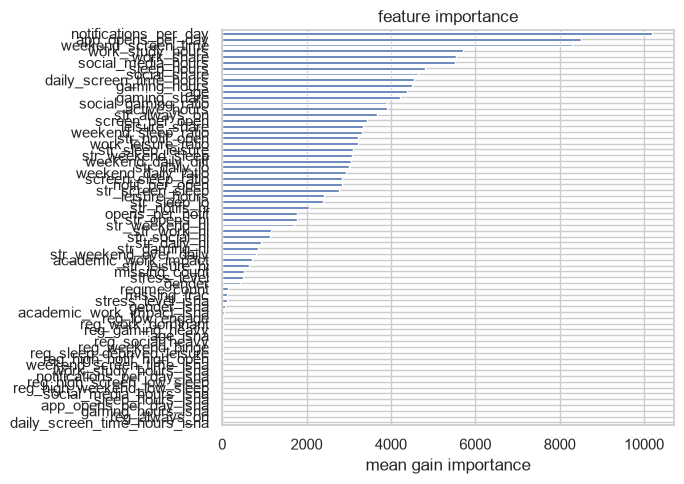

,importance
notifications_per_day,10199.822222
app_opens_per_day,8496.933333
weekend_screen_time,8288.244444
work_study_hours,5699.244444
work_share,5552.711111
...,...
sleep_hours_isna,1.577778
app_opens_per_day_isna,1.533333
gaming_hours_isna,1.066667
reg_always_on,0.266667


In [62]:
imp = importances.mean(axis=1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set(xlabel="mean gain importance", title="feature importance")
plt.tight_layout()
plt.show()

imp.sort_values(ascending=False).to_frame("importance")

## Submission

In [63]:
submission = sample_submission.copy()
submission[TARGET] = test_preds
submission.to_csv("submission.csv")
print(f"oof auc: {oof_score:.5f}")
submission.head()

oof auc: 0.96540


,addicted_label
id,
691369,0.999772
691370,0.963986
691371,0.941045
691372,0.992398
691373,0.998293
